In [1]:
import pandas as pd


In [2]:

df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/311_Service_Requests_from_2019May.csv')

/tmp/ipykernel_892/3324058439.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/311_Service_Requests_from_2019May.csv')


In [3]:
from google.colab import files
uploaded = files.upload()


Saving 311_Service_Requests_from_2019May.csv to 311_Service_Requests_from_2019May.csv


In [5]:
print(df.shape)

(69637, 21)


In [9]:
print(df.columns.tolist())

['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Complaint Type', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'BBL', 'Borough', 'Latitude', 'Longitude', 'Location']


In [25]:
print(pd.to_datetime(df['Created Date']).min())

2019-05-01 00:00:00


In [26]:
print(pd.to_datetime(df['Created Date']).max())

2019-05-10 00:00:00


In [23]:
df.groupby(['Borough'])['Unique Key'].count()

,Unique Key
Borough,
BRONX,10925
BROOKLYN,22247
MANHATTAN,13133
QUEENS,18623
STATEN ISLAND,3848
Unspecified,861


In [29]:
print(pd.to_datetime(df['Created Date']).min())

2019-05-01 00:00:00


In [30]:
print(pd.to_datetime(df['Created Date']).max())

2019-05-10 00:00:00


In [31]:
df['Complaint Type'].unique()

array(['Water System', 'Food Poisoning', 'FATF', 'Noise',
       'Noise - Residential', 'GENERAL', 'HEAT/HOT WATER',
       'Sanitation Condition', 'Blocked Driveway',
       'General Construction/Plumbing',
       'Request Large Bulky Item Collection', 'PAINT/PLASTER',
       'Illegal Parking', 'Noise - Commercial', 'School Maintenance',
       'Noise - Street/Sidewalk', 'DOOR/WINDOW', 'UNSANITARY CONDITION',
       'Street Condition', 'Derelict Vehicle', 'Noise - Vehicle',
       'Electronics Waste', 'Street Light Condition', 'Building/Use',
       'Traffic Signal Condition', 'Damaged Tree', 'Sidewalk Condition',
       'Emergency Response Team (ERT)', 'Elevator', 'Taxi Report',
       'Food Establishment', 'Litter Basket / Request', 'ELECTRIC',
       'Rodent', 'PLUMBING', 'WATER LEAK', 'FLOORING/STAIRS', 'APPLIANCE',
       'Dirty Conditions', 'Non-Emergency Police Matter',
       'Dead/Dying Tree', 'Air Quality', 'Traffic', 'New Tree Request',
       'Homeless Person Assistance', 

In [32]:
import matplotlib.pyplot as plt


Text(0, 0.5, 'Number of Complaints')

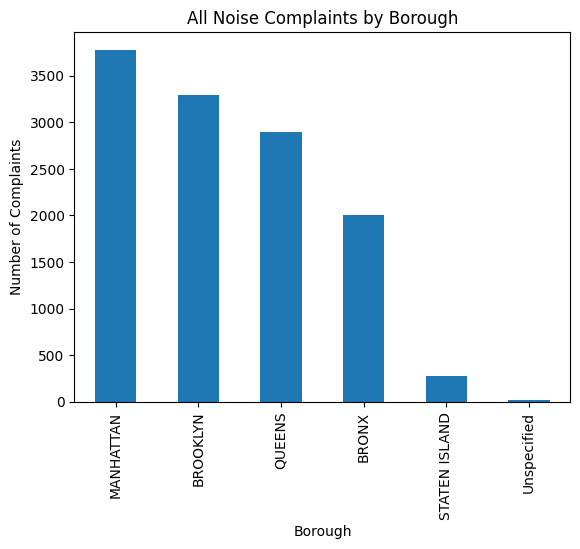

In [35]:
noise_df = df[df['Complaint Type'].str.contains('Noise')]
borough_counts = noise_df['Borough'].value_counts()

borough_counts.plot(kind='bar')
plt.title('All Noise Complaints by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Complaints')



In [38]:
df["Complaint Type"].value_counts()

,count
Complaint Type,
Noise - Residential,5838
Request Large Bulky Item Collection,5301
Illegal Parking,5257
Blocked Driveway,3391
Street Condition,3080
...,...
Highway Sign - Damaged,1
Taxi Compliment,1
Illegal Fireworks,1


In [40]:
df['Borough'].value_counts()

,count
Borough,
BROOKLYN,22247
QUEENS,18623
MANHATTAN,13133
BRONX,10925
STATEN ISLAND,3848
Unspecified,861


Text(0, 0.5, 'Number of Complaints')

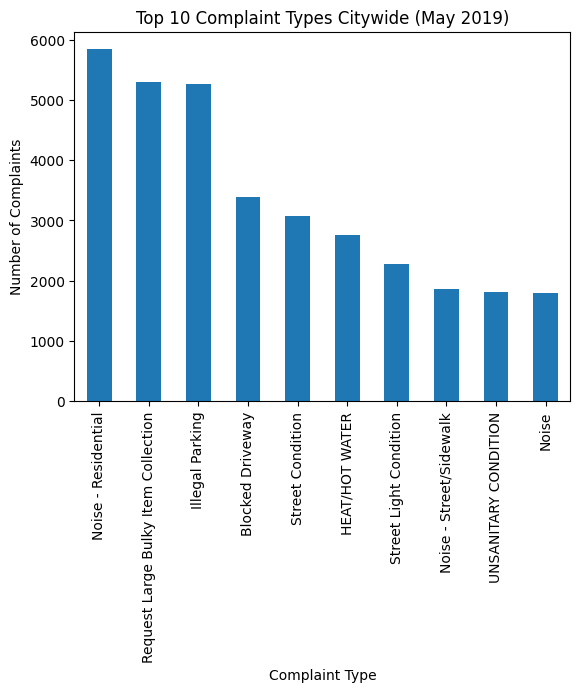

In [41]:
top_complaints = df['Complaint Type'].value_counts().head(10)
top_complaints.plot(kind='bar')
plt.title('Top 10 Complaint Types Citywide (May 2019)')
plt.xlabel('Complaint Type')
plt.ylabel('Number of Complaints')

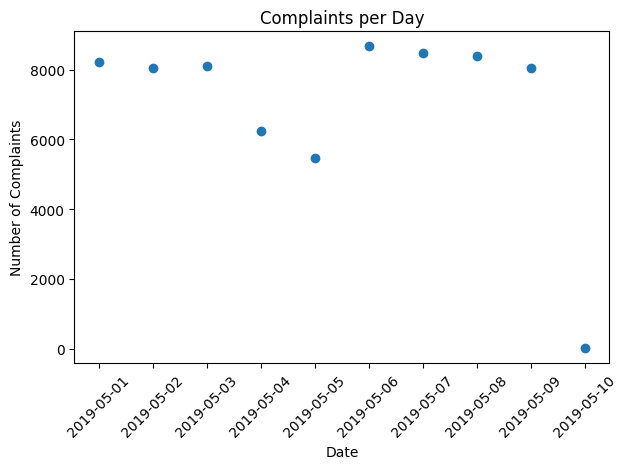

In [54]:
df['Created Date'] = pd.to_datetime(df['Created Date'])

daily = df.groupby(df['Created Date'].dt.date).size()

plt.scatter(daily.index, daily.values)
plt.title('Complaints per Day')
plt.xlabel('Date')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


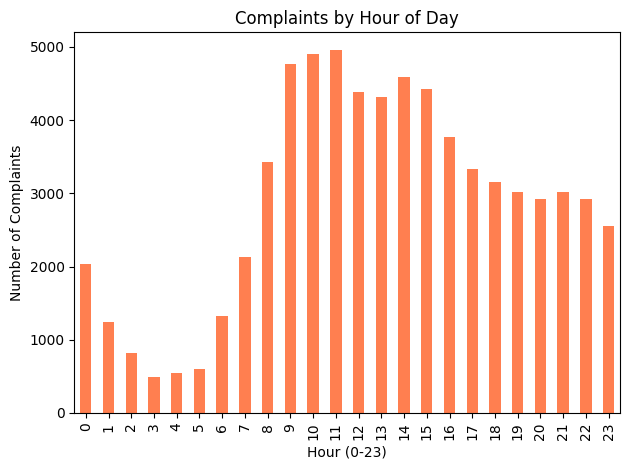

In [55]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Hour'] = df['Created Date'].dt.hour
hour_counts = df['Hour'].value_counts().sort_index()
hour_counts.plot(kind='bar', color='coral')
plt.title('Complaints by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()
